# LeetCode #643: Maximum Average Subarray I

https://leetcode.com/problems/maximum-average-subarray-i/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \cdot k)$ | $O(1)$ |
| **Optimal: Fixed-Size Sliding Window** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
For every valid starting index $i$, sum the $k$ elements starting at $i$ and track the maximum sum. Requires recomputing the sum from scratch for each window — $O(n \cdot k)$ total work.

### Optimal: Fixed-Size Sliding Window ★
Compute the sum of the first $k$ elements. Then slide the window one step at a time: add the new right element, subtract the old left element. Each slide is $O(1)$, giving $O(n)$ total.

**Why this is better than brute force:** Reuses $k-1$ of the $k$ additions from the previous window instead of recomputing from scratch. The gap widens as $k$ grows.

**Constraints:**
* `n == nums.length`
* `1 <= k <= n <= 10^5`
* `-10^4 <= nums[i] <= 10^4`

## Solutions

### C#

In [ ]:
public class Solution {
    public double FindMaxAverage(int[] nums, int k) {
        // Build the first window sum
        int windowSum = 0;
        for (int i = 0; i < k; i++) windowSum += nums[i];
        int maxSum = windowSum;
        // Slide the window: add right element, drop left element
        for (int i = k; i < nums.Length; i++) {
            windowSum += nums[i] - nums[i - k];
            if (windowSum > maxSum) maxSum = windowSum;
        }
        return (double)maxSum / k;
    }
}

### Python

In [ ]:
class Solution:
    def findMaxAverage(self, nums: list[int], k: int) -> float:
        # Build the first window sum
        window_sum = sum(nums[:k])
        max_sum = window_sum
        # Slide the window: add right element, drop left element
        for i in range(k, len(nums)):
            window_sum += nums[i] - nums[i - k]
            if window_sum > max_sum:
                max_sum = window_sum
        return max_sum / k

### Go

In [ ]:
func findMaxAverage(nums []int, k int) float64 {
    // Build the first window sum
    windowSum := 0
    for i := 0; i < k; i++ {
        windowSum += nums[i]
    }
    maxSum := windowSum
    // Slide the window: add right element, drop left element
    for i := k; i < len(nums); i++ {
        windowSum += nums[i] - nums[i-k]
        if windowSum > maxSum {
            maxSum = windowSum
        }
    }
    return float64(maxSum) / float64(k)
}

### Rust

In [ ]:
impl Solution {
    pub fn find_max_average(nums: Vec<i32>, k: i32) -> f64 {
        let k = k as usize;
        // Build the first window sum
        let mut window_sum: i32 = nums[..k].iter().sum();
        let mut max_sum = window_sum;
        // Slide the window: add right element, drop left element
        for i in k..nums.len() {
            window_sum += nums[i] - nums[i - k];
            if window_sum > max_sum {
                max_sum = window_sum;
            }
        }
        max_sum as f64 / k as f64
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [1,12,-5,-6,50,3]`, `k = 4`
First window `[1,12,-5,-6]` sums to 2; slide to `[12,-5,-6,50]` = 51; slide to `[-5,-6,50,3]` = 42. Max sum = 51, avg = **12.75**.

### 2. Slightly Complex
**Input:** `nums = [5,5,5,5,5]`, `k = 3`
Every window sums to 15, so max = 15 and avg = **5.0**. Confirms the algorithm handles uniform arrays correctly without a false peak.

### 3. Edge Case: Time Factor
**Input:** `nums = [-10000, -10000, ..., -10000, 10000]` (99999 negatives then one 10000), `k = 1`
The max window `[10000]` sits at the last index, forcing a full scan of $n-1$ negative windows before finding the peak — worst case for the number of slide steps.

### 4. Edge Case: Space Factor
**Input:** `nums = [0, 0, ..., 0]` (100000 zeros), `k = 50000`
Only two window positions exist; window sum stays 0 throughout. No auxiliary storage is needed — just two integer variables, confirming $O(1)$ space even at maximum $n$.

### 5. Almost-Impossible but Plausible
**Input:** `nums = [-10000, 10000]`, `k = 2`
Window sum = 0, avg = **0.0**. Tests a negative–positive pairing at the extreme boundary values with $k = n$, exercising the single-window case where no sliding ever occurs.

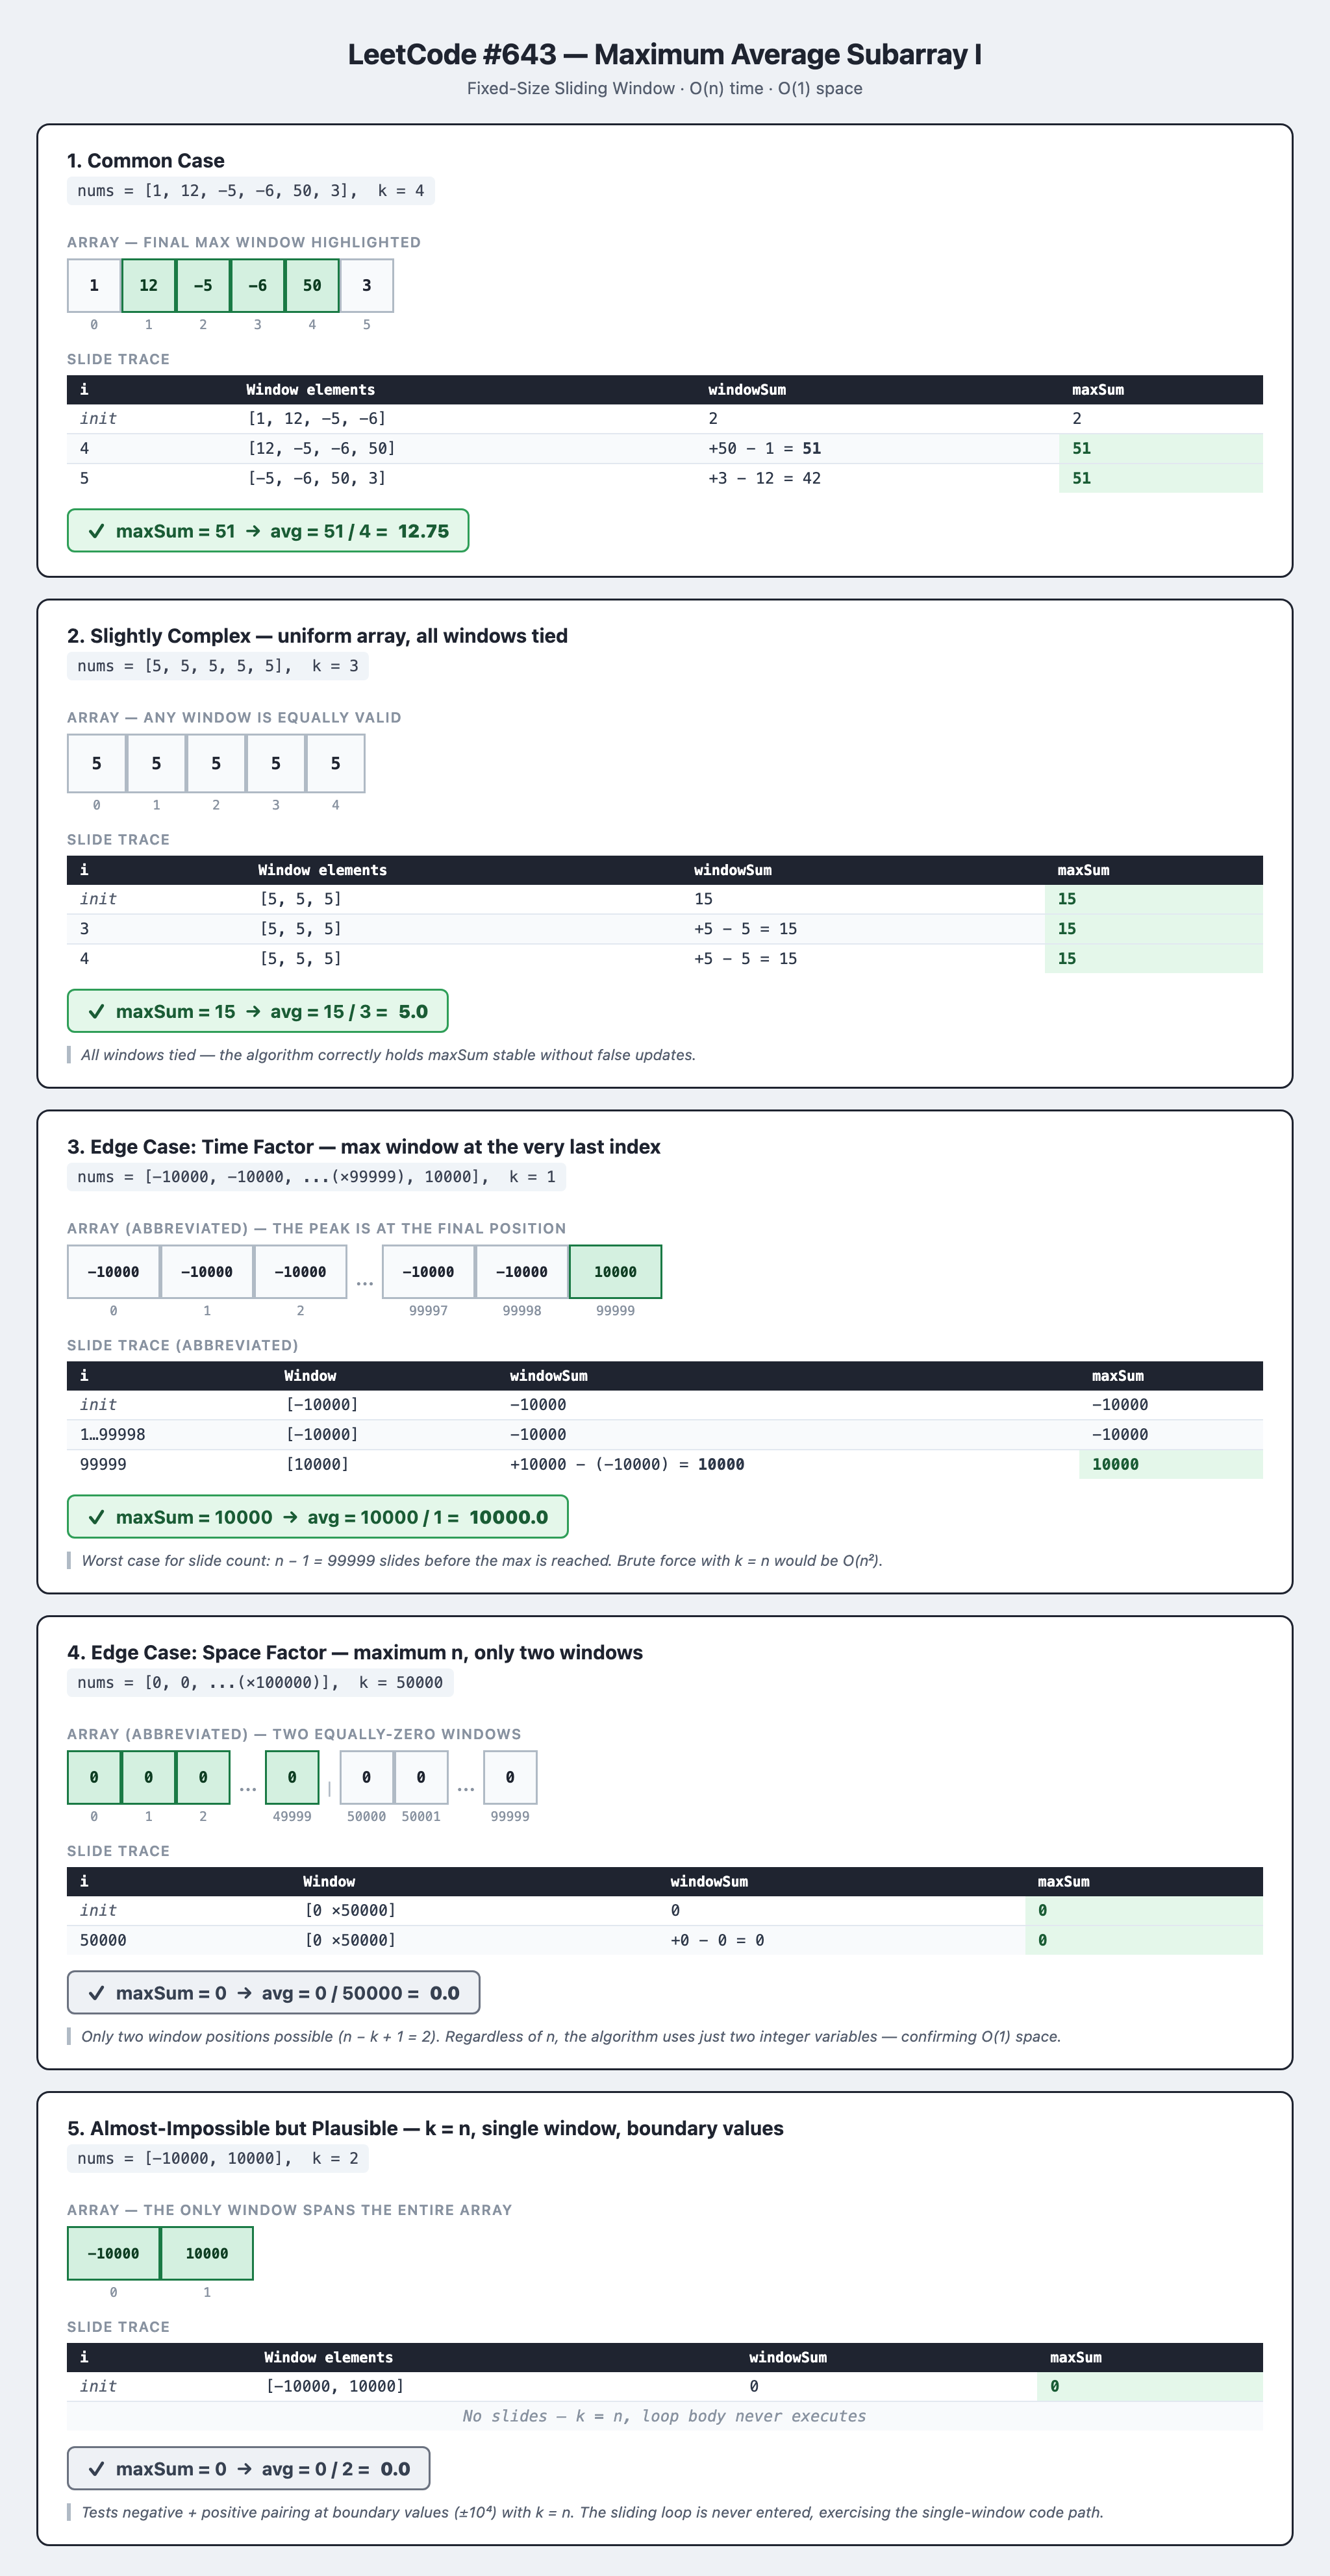